## Machine Learning - Assignment 2
## Multiclass Classification of Dry Bean Varieties

### 1. Importing libraries

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
%pip install openpyxl

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Libraries imported successfully.


### 2. Loading the dataset

In [2]:
# Setting the filename of the downloaded UCI Dry Bean dataset here.
DATA_FILE = "Dry_Bean_Dataset.xlsx"

if not os.path.exists(DATA_FILE):
    csv_candidate = "Dry_Bean_Dataset.csv"
    if os.path.exists(csv_candidate):
        DATA_FILE = csv_candidate
    else:
        raise FileNotFoundError(
            "Dataset file not found. Download the UCI Dry Bean Dataset "
            "and place the Excel/CSV file in the same folder as this notebook."
        )

if DATA_FILE.lower().endswith((".xlsx", ".xls")):
    df = pd.read_excel(DATA_FILE)
elif DATA_FILE.lower().endswith(".csv"):
    df = pd.read_csv(DATA_FILE)
else:
    raise ValueError("Use an Excel (.xlsx/.xls) or CSV (.csv) dataset file.")

print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully.
Shape: (13611, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


### 3. Understanding the data

In [3]:
print("First five observations:")
display(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types and non-null counts:")
df.info()

First five observations:


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER



Dataset shape:
(13611, 17)

Column names:
['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4', 'Class']

Data types and non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 

#### 3.1. Descriptive statistics theory

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Area,13611.0,53048.284549,29324.095717,20420.000000,36328.000000,44652.000000,61332.000000,254616.000000
Perimeter,13611.0,855.283459,214.289696,524.736000,703.523500,794.941000,977.213000,1985.370000
MajorAxisLength,13611.0,320.141867,85.694186,183.601165,253.303633,296.883367,376.495012,738.860153
MinorAxisLength,13611.0,202.270714,44.970091,122.512653,175.848170,192.431733,217.031741,460.198497
AspectRation,13611.0,1.583242,0.246678,1.024868,1.432307,1.551124,1.707109,2.430306
Eccentricity,13611.0,0.750895,0.092002,0.218951,0.715928,0.764441,0.810466,0.911423
ConvexArea,13611.0,53768.200206,29774.915817,20684.000000,36714.500000,45178.000000,62294.000000,263261.000000
EquivDiameter,13611.0,253.064220,59.177120,161.243764,215.068003,238.438026,279.446467,569.374358
Extent,13611.0,0.749733,0.049086,0.555315,0.718634,0.759859,0.786851,0.866195
Solidity,13611.0,0.987143,0.004660,0.919246,0.985670,0.988283,0.990013,0.994677


#### 3.2. Missing values

In [5]:
missing_values = df.isnull().sum()

print("Missing values by column:")
display(missing_values.to_frame("Missing Values"))

print("Total missing values:", int(missing_values.sum()))

Missing values by column:


,Missing Values
Area,0
Perimeter,0
MajorAxisLength,0
MinorAxisLength,0
AspectRation,0
Eccentricity,0
ConvexArea,0
EquivDiameter,0
Extent,0
Solidity,0


Total missing values: 0


#### 3.3. Duplicate observations

In [6]:
duplicate_count = int(df.duplicated().sum())
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 68


### 4. Target Variable 

In [7]:
target_column = "Class"

if target_column not in df.columns:
    raise KeyError(
        f"Expected target column '{target_column}' was not found. "
        f"Available columns are: {df.columns.tolist()}"
    )

print("Target variable:", target_column)
print("\nUnique classes:")
print(df[target_column].unique())

Target variable: Class

Unique classes:
<ArrowStringArray>
['SEKER', 'BARBUNYA', 'BOMBAY', 'CALI', 'HOROZ', 'SIRA', 'DERMASON']
Length: 7, dtype: str


#### 4.1 Class distribution

Class counts:


,Count
Class,
DERMASON,3546
SIRA,2636
SEKER,2027
HOROZ,1928
CALI,1630
BARBUNYA,1322
BOMBAY,522


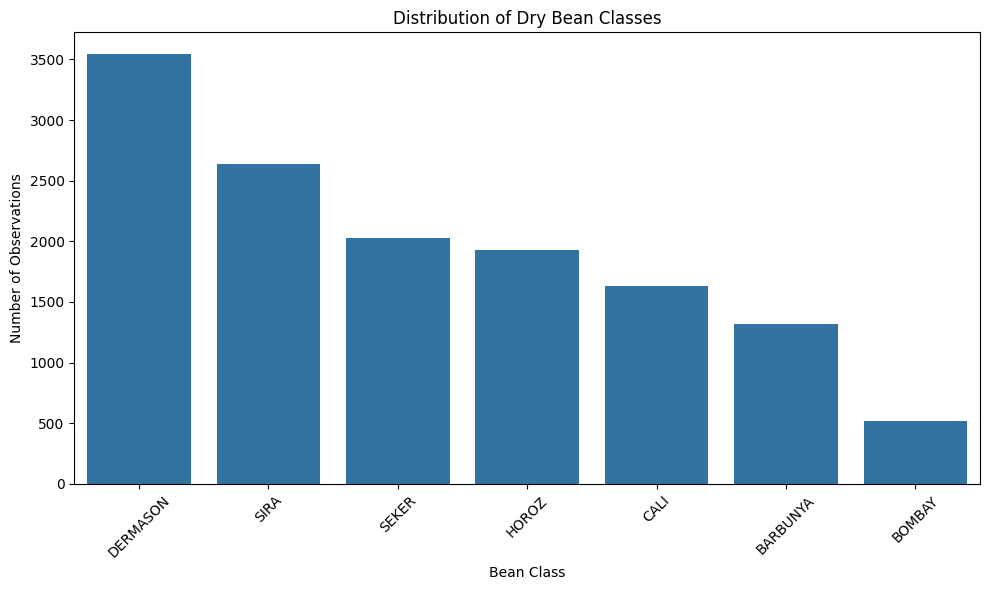

In [8]:
class_counts = df[target_column].value_counts()

print("Class counts:")
display(class_counts.to_frame("Count"))

plt.figure(figsize=(10, 6))
sns.countplot(
    data=df,
    x=target_column,
    order=class_counts.index
)
plt.title("Distribution of Dry Bean Classes")
plt.xlabel("Bean Class")
plt.ylabel("Number of Observations")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 5. Feature Exploration

Number of numerical features: 16

Numerical features:
['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4']


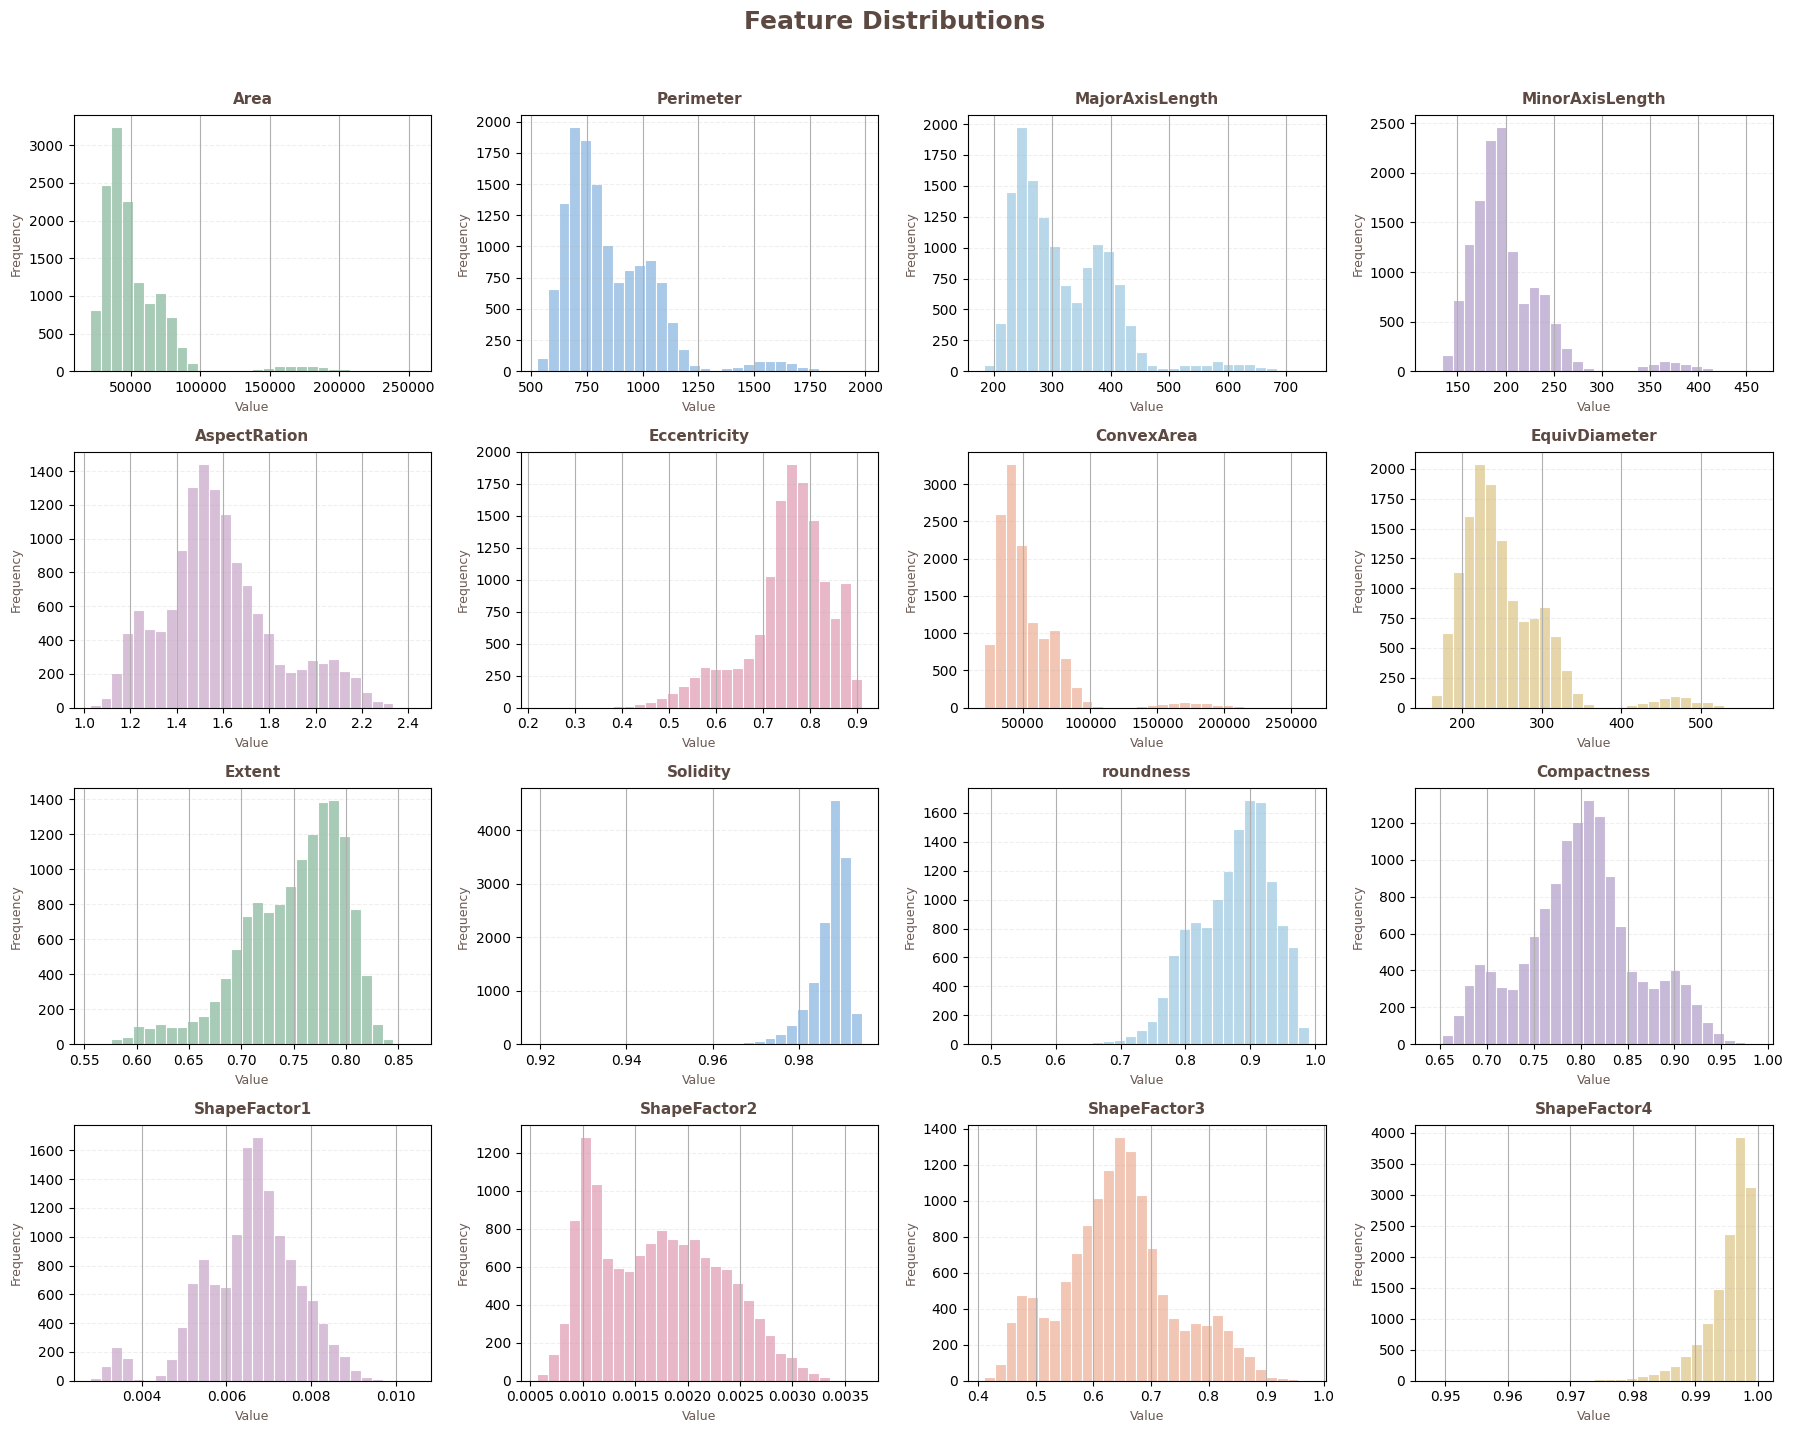

In [9]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

print(
    "Number of numerical features:",
    len(numeric_columns)
)

print("\nNumerical features:")
print(numeric_columns)

pastel_palette = [
    "#A8CBB7",  
    "#A9C9E8",  
    "#B8D8EA",  
    "#C7B9D8",  
    "#D8BFD8", 
    "#E8B7C8",  
    "#F2C6B4",  
    "#E6D5A8",  
]

axes = df[numeric_columns].hist(
    figsize=(18, 14),
    bins=30,
    edgecolor="#FFFFFF",
    linewidth=0.8
)

axes = np.array(axes).flatten()

for i, ax in enumerate(axes):

    # Skip unused subplot spaces
    if i >= len(numeric_columns):
        ax.set_visible(False)
        continue
    colour = pastel_palette[
        i % len(pastel_palette)
    ]

    for patch in ax.patches:
        patch.set_facecolor(colour)

    ax.set_title(
        numeric_columns[i],
        fontsize=11,
        fontweight="bold",
        color="#5C4A42",
        pad=8
    )
    ax.set_xlabel(
        "Value",
        fontsize=9,
        color="#6B5A52"
    )

    ax.set_ylabel(
        "Frequency",
        fontsize=9,
        color="#6B5A52"
    )

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.20
    )

plt.suptitle(
    "Feature Distributions",
    fontsize=18,
    fontweight="bold",
    color="#5C4A42",
    y=1.02
)


#layout
plt.tight_layout()
plt.show()

#### 5.1. Correlation heatmap

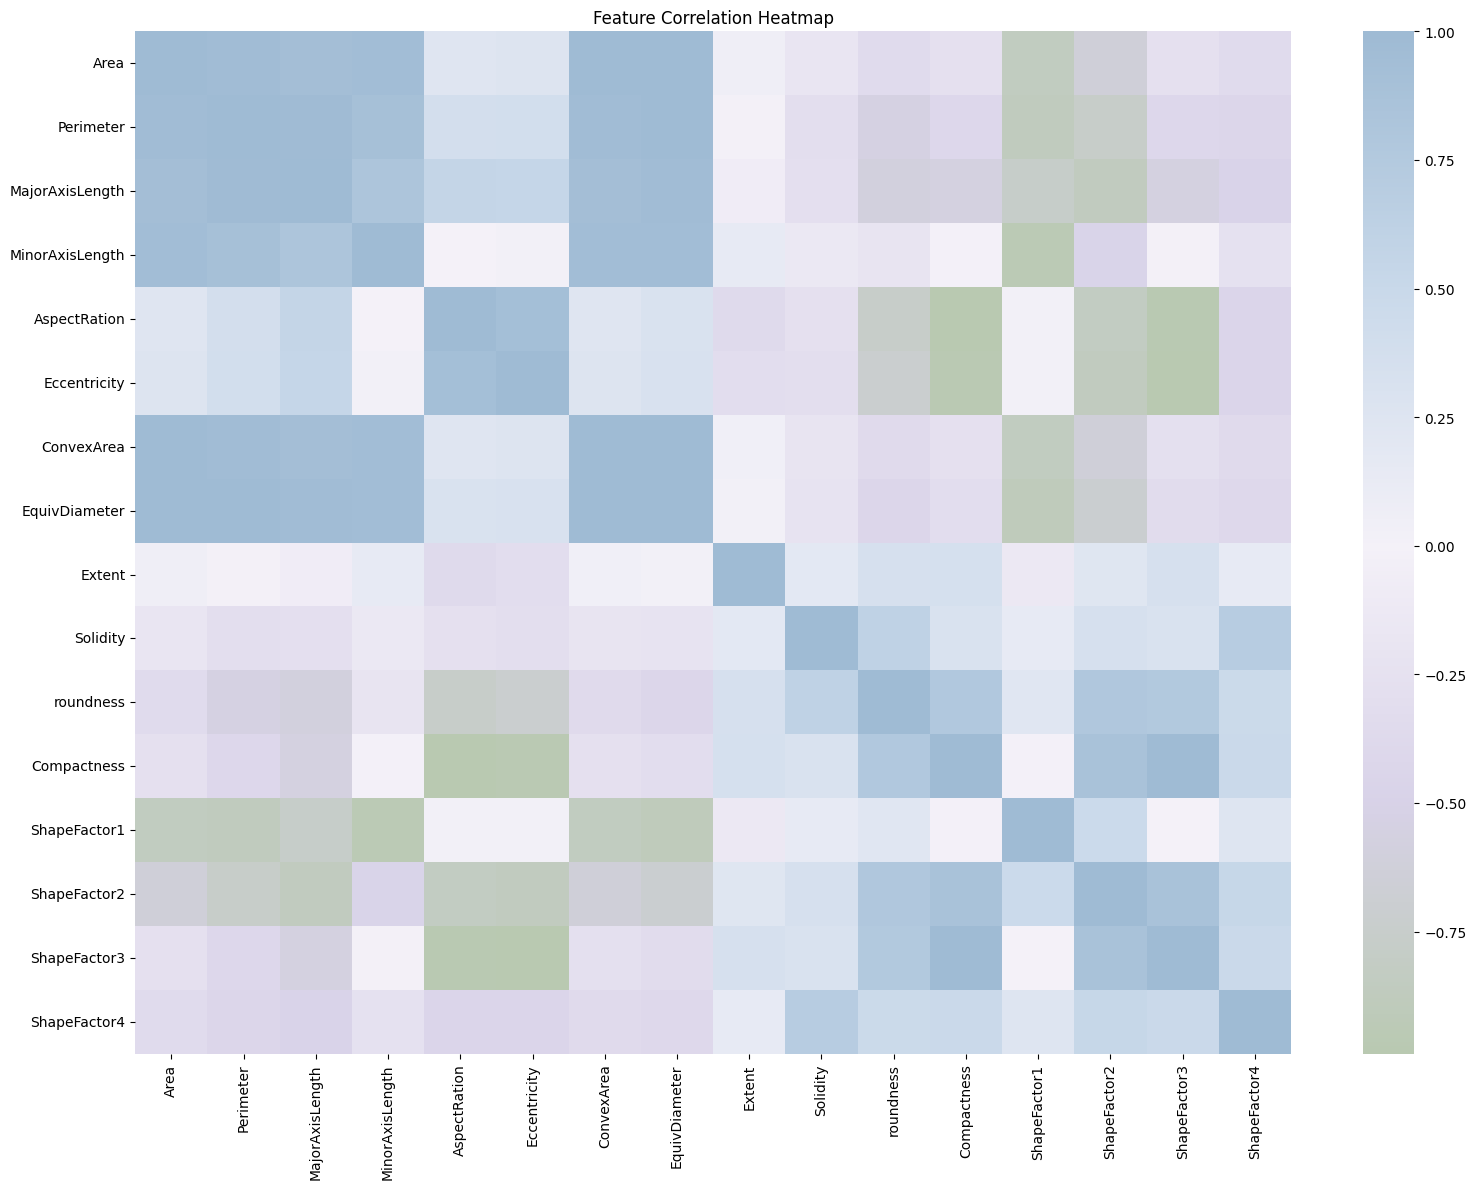

In [10]:
plt.figure(figsize=(16, 12))

correlation_matrix = df[numeric_columns].corr()
custom_cmap = sns.blend_palette(
    [
        "#B8C9B0",  
        "#D8D2E8", 
        "#F4F1F8", 
        "#C9D9EA", 
        "#9FBBD4"  
    ],
    as_cmap=True
)
sns.heatmap(
    correlation_matrix,
    cmap=custom_cmap,
    center=0,
    annot=False
)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

### 6. Separating feature and Target

In [11]:
X = df.drop(columns=[target_column])
y = df[target_column]
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (13611, 16)
Target shape: (13611,)


### 7. Label Encoding

In [12]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print("Class mapping:")
for number, class_name in enumerate(label_encoder.classes_):
    print(f"{number} → {class_name}")

Class mapping:
0 → BARBUNYA
1 → BOMBAY
2 → CALI
3 → DERMASON
4 → HOROZ
5 → SEKER
6 → SIRA


### 8. Train/ Test Split of data

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)
print("Training observations:", X_train.shape[0])
print("Testing observations:", X_test.shape[0])
print("Number of features:", X_train.shape[1])

Training observations: 10888
Testing observations: 2723
Number of features: 16


### 9. Model Implementation

#### 9.1. Logistic Regression 
Logistic Regression is a supervised classification algorithm.

For binary classification, it uses the sigmoid function:

σ(z) = 1 / (1 + e⁻ᶻ)

where:

z = β₀ + β₁x₁ + β₂x₂ + ... + βₙxₙ

For multiclass classification, Logistic Regression can model multiple classes.

In [14]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

logistic_predictions = logistic_model.predict(X_test)
logistic_probabilities = logistic_model.predict_proba(X_test)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


#### 9.2 Decision Tree — Theory
A Decision Tree predicts a class by repeatedly splitting observations according to feature conditions.

Conceptually:

              Feature A < threshold?
                 /             \
               Yes              No
               /                 \
          Feature B?          Feature C?
The final nodes are called leaves.

In [15]:
decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_model.fit(X_train, y_train)

decision_tree_predictions = decision_tree_model.predict(X_test)
decision_tree_probabilities = decision_tree_model.predict_proba(X_test)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


#### 9.3. K-Nearest Neighbours (kNN) — Theory
kNN is an instance-based classification algorithm.
For a new observation we follow the below steps ideally: 
1. Calculate its distance from training observations.
2. Identify the k nearest observations.
3. Examine their class labels.
4. Assign the most supported class.
5. For example, with k = 5, the five closest training observations vote on the predicted class.

In [16]:
knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", KNeighborsClassifier(
        n_neighbors=5
    ))
])

knn_model.fit(X_train, y_train)

knn_predictions = knn_model.predict(X_test)
knn_probabilities = knn_model.predict_proba(X_test)

print("kNN trained successfully.")

kNN trained successfully.


#### 9.4 Gaussian Naive Bayes — Theory
Naive Bayes is based on Bayes' theorem:

P(C|X) = P(X|C)P(C) / P(X)

where:

C = class
X = observed features
The naive assumption is that features are conditionally independent given the class.

Gaussian Naive Bayes additionally assumes that numerical features follow approximately Gaussian distributions within each class.

In [17]:
naive_bayes_model = GaussianNB()

naive_bayes_model.fit(X_train, y_train)

naive_bayes_predictions = naive_bayes_model.predict(X_test)
naive_bayes_probabilities = naive_bayes_model.predict_proba(X_test)

print("Gaussian Naive Bayes trained successfully.")

Gaussian Naive Bayes trained successfully.


#### 9.5. Random Forest — Theory
Random Forest is an ensemble learning algorithm.

Instead of relying on one decision tree, Random Forest trains multiple trees and combines their predictions.

Conceptually:

                 Dataset
                    |
        -------------------------
        |           |           |
      Tree 1      Tree 2      Tree 3
        |           |           |
        -------------------------
                    |
             Final prediction
Random Forest introduces randomness in the observations and features used to construct individual trees. Combining many trees can improve generalisation compared with relying on one tree.

In [18]:
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train, y_train)

random_forest_predictions = random_forest_model.predict(X_test)
random_forest_probabilities = random_forest_model.predict_proba(X_test)

print("Random Forest trained successfully.")

Random Forest trained successfully.


### 10. Evalvation metrics

In [19]:
def evaluate_model(model_name, y_true, y_pred, y_prob):
    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    mcc = matthews_corrcoef(
        y_true,
        y_pred
    )

    auc = roc_auc_score(
        y_true,
        y_prob,
        multi_class="ovr",
        average="weighted"
    )

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "AUC": auc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "MCC": mcc
    }


results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        logistic_predictions,
        logistic_probabilities
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        decision_tree_predictions,
        decision_tree_probabilities
    )
)

results.append(
    evaluate_model(
        "kNN",
        y_test,
        knn_predictions,
        knn_probabilities
    )
)

results.append(
    evaluate_model(
        "Naive Bayes",
        y_test,
        naive_bayes_predictions,
        naive_bayes_probabilities
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        random_forest_predictions,
        random_forest_probabilities
    )
)

results_df = pd.DataFrame(results)

display(results_df.round(4))

,Model,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.9214,0.9934,0.9222,0.9214,0.9216,0.9050
1,Decision Tree,0.8917,0.9330,0.8912,0.8917,0.8913,0.8691
2,kNN,0.9166,0.9812,0.9174,0.9166,0.9168,0.8992
3,Naive Bayes,0.7639,0.9644,0.7654,0.7639,0.7615,0.7154
4,Random Forest,0.9221,0.9920,0.9222,0.9221,0.9221,0.9058


In [20]:
#Formatting the above results as required for readabilitya nd comprehension
formatted_results = results_df.copy()

metric_columns = [
    "Accuracy",
    "AUC",
    "Precision",
    "Recall",
    "F1",
    "MCC"
]

formatted_results[metric_columns] = (
    formatted_results[metric_columns] * 100
).round(2)

display(formatted_results)

,Model,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,92.14,99.34,92.22,92.14,92.16,90.50
1,Decision Tree,89.17,93.30,89.12,89.17,89.13,86.91
2,kNN,91.66,98.12,91.74,91.66,91.68,89.92
3,Naive Bayes,76.39,96.44,76.54,76.39,76.15,71.54
4,Random Forest,92.21,99.20,92.22,92.21,92.21,90.58


### 10. Confusion matrix

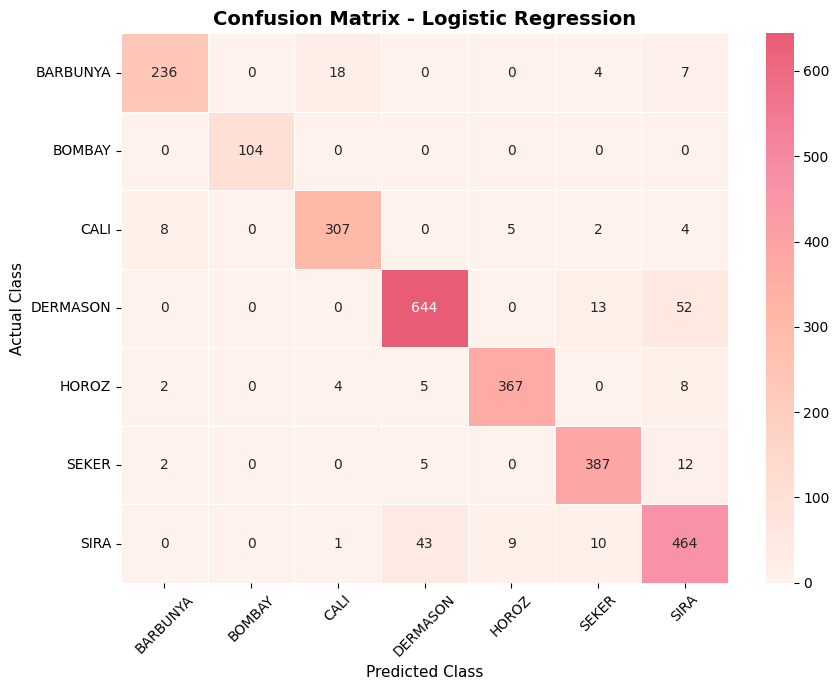

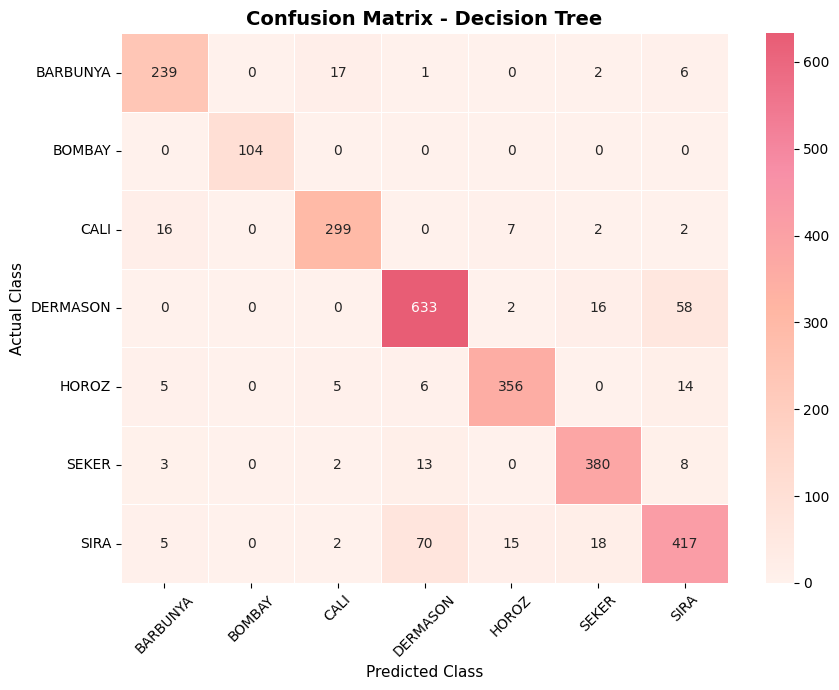

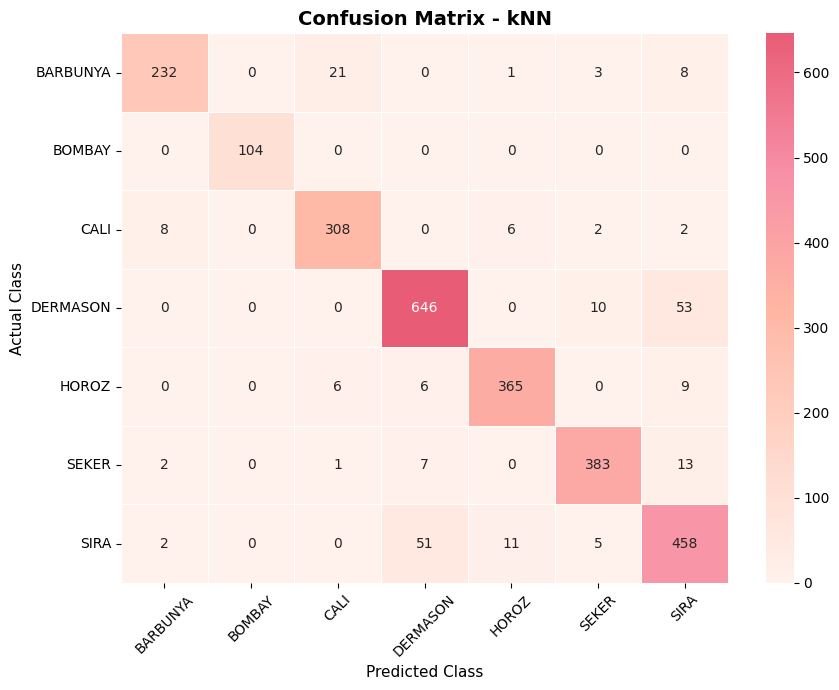

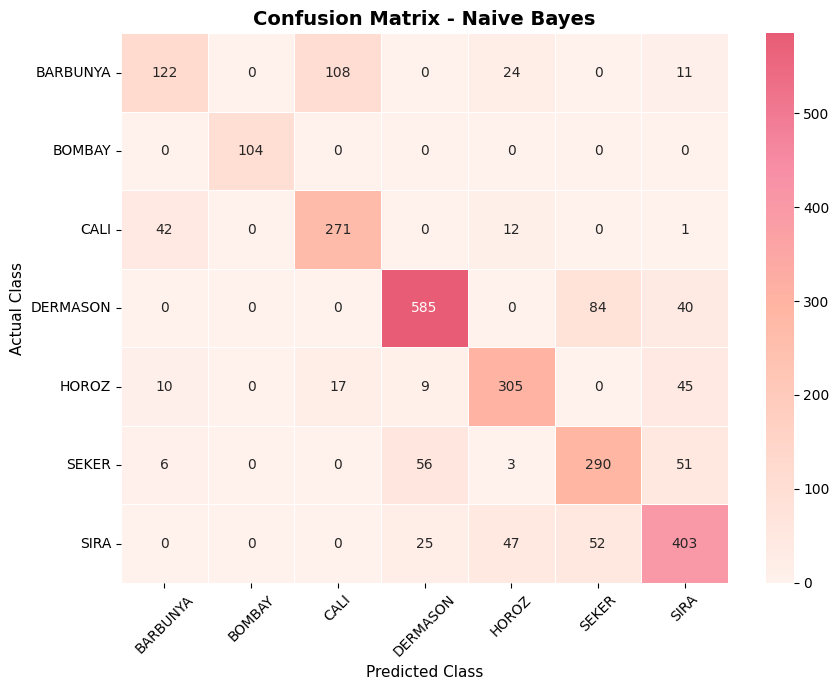

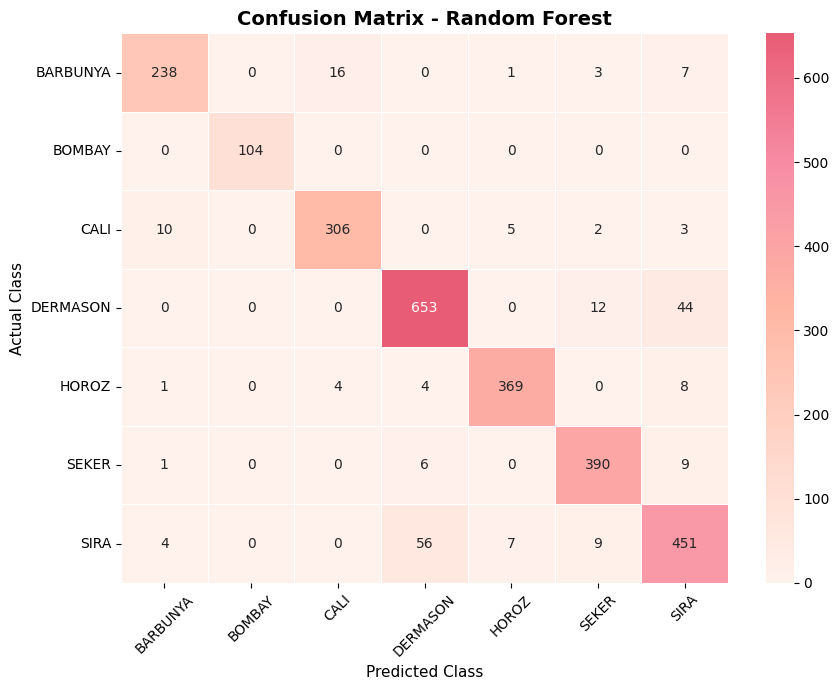

In [21]:
from matplotlib.colors import LinearSegmentedColormap

pink_peach = LinearSegmentedColormap.from_list(
    "PinkPeach",
    [
        "#FFF1EC",  
        "#FFD6C9", 
        "#FFB6A3",  
        "#F78FA7",  
        "#E85D75"   
    ]
)
model_predictions = {
    "Logistic Regression": logistic_predictions,
    "Decision Tree": decision_tree_predictions,
    "kNN": knn_predictions,
    "Naive Bayes": naive_bayes_predictions,
    "Random Forest": random_forest_predictions
}

for model_name, predictions in model_predictions.items():

    cm = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(9, 7))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=pink_peach,
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_,
        linewidths=0.7,
        linecolor="white"
    )

    plt.title(
        f"Confusion Matrix - {model_name}",
        fontsize=14,
        fontweight="bold"
    )

    plt.xlabel("Predicted Class", fontsize=11)
    plt.ylabel("Actual Class", fontsize=11)

    plt.xticks(rotation=45)
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()
    plt.close()

### 11. Classification report

In [22]:
for model_name, predictions in model_predictions.items():
    print("=" * 75)
    print(model_name)
    print("=" * 75)

    print(
        classification_report(
            y_test,
            predictions,
            target_names=label_encoder.classes_,
            zero_division=0
        )
    )

Logistic Regression
              precision    recall  f1-score   support

    BARBUNYA       0.95      0.89      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.93      0.94      0.94       326
    DERMASON       0.92      0.91      0.92       709
       HOROZ       0.96      0.95      0.96       386
       SEKER       0.93      0.95      0.94       406
        SIRA       0.85      0.88      0.86       527

    accuracy                           0.92      2723
   macro avg       0.94      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723

Decision Tree
              precision    recall  f1-score   support

    BARBUNYA       0.89      0.90      0.90       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.92      0.92      0.92       326
    DERMASON       0.88      0.89      0.88       709
       HOROZ       0.94      0.92      0.93       386
       SEKER       0.91      0.94      0.92 

### 12. Visual model Comparision

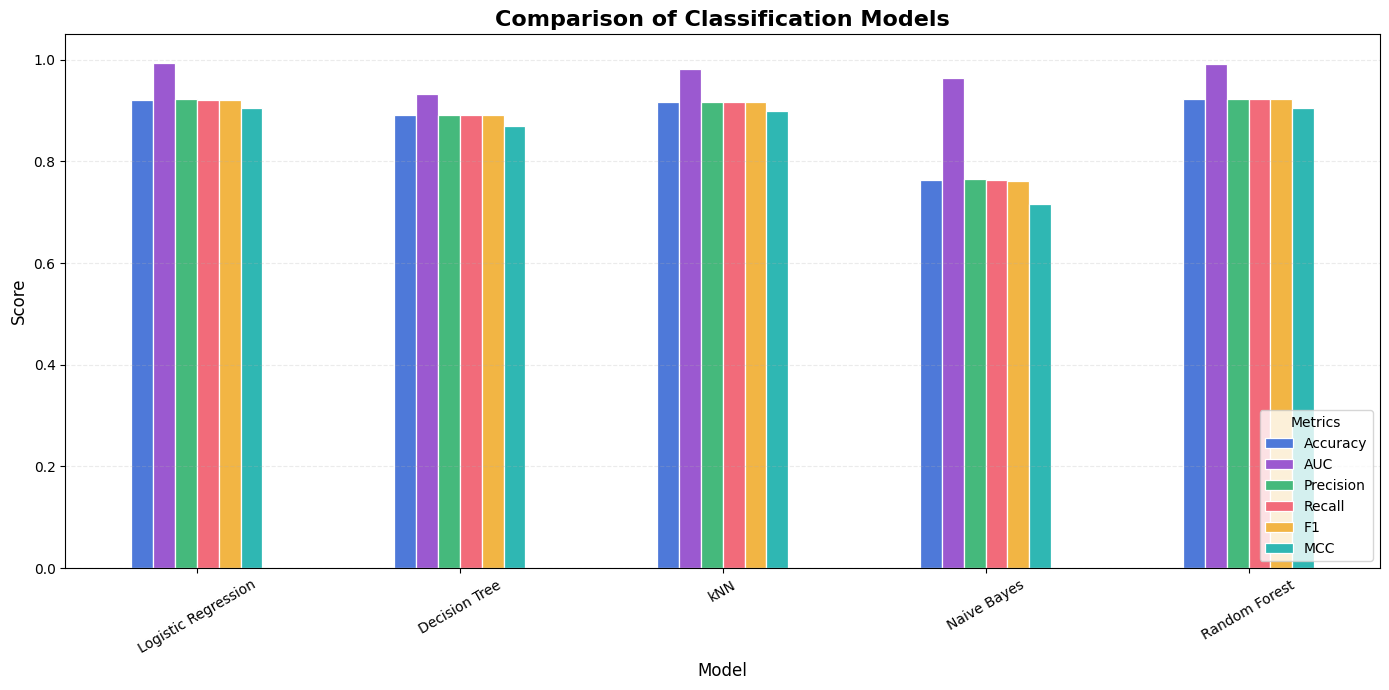

In [23]:
plot_df = results_df.set_index("Model")

ax = plot_df[
    ["Accuracy", "AUC", "Precision", "Recall", "F1", "MCC"]
].plot(
    kind="bar",
    figsize=(14, 7),
    color=[
        "#4E79D9",  
        "#9B59D0",  
        "#45B97C",  
        "#F26B7A",  
        "#F2B544",  
        "#2FB7B3"   
    ],
    edgecolor="white",
    linewidth=0.9
)

plt.title(
    "Comparison of Classification Models",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Score", fontsize=12)
plt.xlabel("Model", fontsize=12)

plt.xticks(rotation=30)
plt.ylim(0, 1.05)

plt.legend(
    title="Metrics",
    loc="lower right",
    frameon=True
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

plt.tight_layout()
plt.show()

### 13. Selecting a winner

In [24]:
average_scores = results_df.copy()

average_scores["Average Score"] = (
    average_scores[metric_columns].mean(axis=1)
)

average_scores = average_scores.sort_values(
    by="Average Score",
    ascending=False
)

display(
    average_scores[
        ["Model", "Average Score"]
    ].round(4)
)

best_model_name = average_scores.iloc[0]["Model"]

print("Overall best model based on mean of the six metrics:")
print(best_model_name)

,Model,Average Score
4,Random Forest,0.9311
0,Logistic Regression,0.9308
2,kNN,0.9247
1,Decision Tree,0.8947
3,Naive Bayes,0.7891


Overall best model based on mean of the six metrics:
Random Forest


### 14. Model performance Observation

In [25]:
# Optional helper: print the best model for each metric.
for metric in metric_columns:
    best_row = results_df.loc[results_df[metric].idxmax()]
    print(f"{metric}: {best_row['Model']} ({best_row[metric]:.4f})")

Accuracy: Random Forest (0.9221)
AUC: Logistic Regression (0.9934)
Precision: Logistic Regression (0.9222)
Recall: Random Forest (0.9221)
F1: Random Forest (0.9221)
MCC: Random Forest (0.9058)


### 15. Feature importance for best model - Random forest

,Feature,Importance
14,ShapeFactor3,0.108350
1,Perimeter,0.092708
11,Compactness,0.086687
12,ShapeFactor1,0.084266
3,MinorAxisLength,0.080861
2,MajorAxisLength,0.075826
6,ConvexArea,0.070672
0,Area,0.063759
5,Eccentricity,0.062618
7,EquivDiameter,0.058248


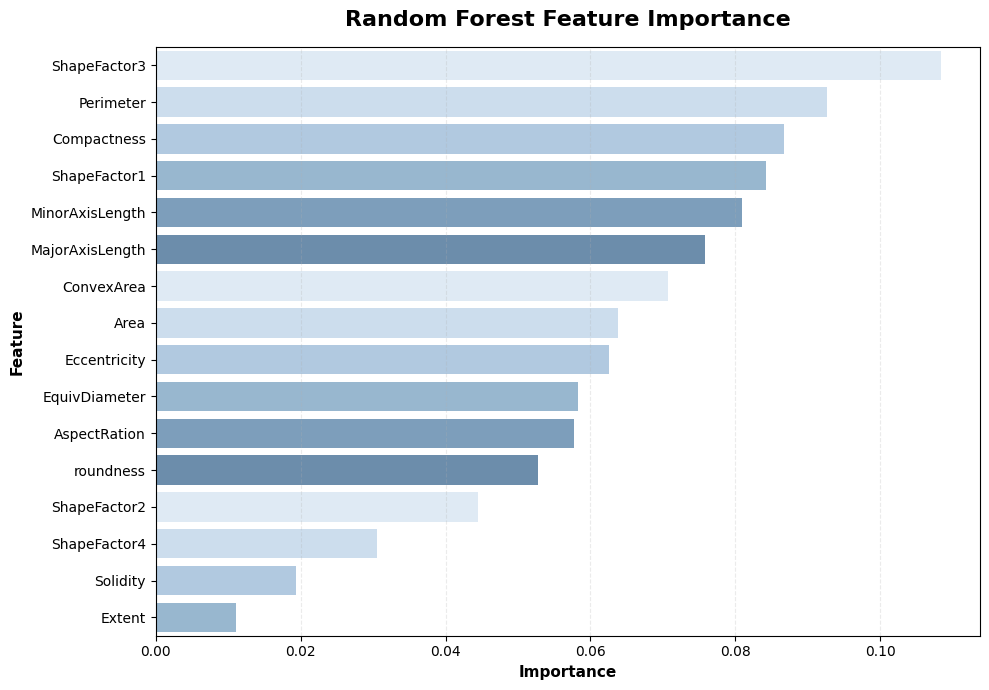

In [26]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance)

blue_palette = [
    "#DCEAF7",  
    "#C6DDF2",  
    "#A9C9E8",  
    "#8FB8D8",  
    "#739FC5",  
    "#628EB5",  
]

plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette=blue_palette,
    legend=False
)

plt.title(
    "Random Forest Feature Importance",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Importance",
    fontsize=11,
    fontweight="bold"
)

plt.ylabel(
    "Feature",
    fontsize=11,
    fontweight="bold"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

plt.tight_layout()
plt.show()
plt.close()

### 16. Creating test_data.csv

In [27]:
test_data = X_test.copy()

test_data[target_column] = label_encoder.inverse_transform(y_test)

test_data.to_csv(
    "test_data.csv",
    index=False
)

print("test_data.csv created successfully.")
print("Shape:", test_data.shape)
display(test_data.head())

test_data.csv created successfully.
Shape: (2723, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
12803,36002,700.889,257.888986,178.268649,1.446631,0.722605,36368,214.100841,0.797386,0.989936,0.920954,0.830205,0.007163,0.002099,0.689241,0.997078,DERMASON
3713,183825,1594.423,582.225240,402.762055,1.445581,0.722124,185116,483.790512,0.797852,0.993026,0.908672,0.830934,0.003167,0.000931,0.690451,0.998102,BOMBAY
8974,45595,801.717,301.092828,193.505323,1.555992,0.766138,46054,240.942643,0.769926,0.990033,0.891425,0.800227,0.006604,0.001670,0.640363,0.996401,SIRA
1743,45084,763.811,261.138204,219.977872,1.187111,0.538882,45425,239.588672,0.773098,0.992493,0.971092,0.917478,0.005792,0.002532,0.841767,0.999271,SEKER
2303,61645,952.199,335.139136,235.843970,1.421021,0.710478,62499,280.158619,0.795522,0.986336,0.854382,0.835947,0.005437,0.001638,0.698808,0.993020,BARBUNYA


### 17. Saving models and verification

In [28]:
loaded_rf = joblib.load("model/random_forest.pkl")
loaded_label_encoder = joblib.load("model/label_encoder.pkl")

loaded_predictions = loaded_rf.predict(X_test)

print("Loaded Random Forest successfully.")
print("Predictions identical to original model:",
      np.array_equal(loaded_predictions, random_forest_predictions))

Loaded Random Forest successfully.
Predictions identical to original model: True


In [29]:
import joblib

# 1. Save the five trained classification models
joblib.dump(logistic_model, "logistic_regression.pkl")
joblib.dump(decision_tree_model, "decision_tree.pkl")
joblib.dump(knn_model, "knn.pkl")
joblib.dump(naive_bayes_model, "naive_bayes.pkl")
joblib.dump(random_forest_model, "random_forest.pkl")

print("Five trained models saved successfully.")

# 2. Find and save the Label Encoder

if "label_encoder" in globals():

    joblib.dump(label_encoder, "label_encoder.pkl")
    print("Label encoder saved successfully.")

else:

    print("'label_encoder' - Not Found.")
    print("Please check the variable name used for the LabelEncoder.")

# 3. Find and save the scaler, if one exists

# Common names that may have been used in the notebook
possible_scaler_names = [
    "scaler",
    "standard_scaler",
    "std_scaler",
    "scaler_obj",
    "standardScaler"
]

scaler_found = False

for scaler_name in possible_scaler_names:

    if scaler_name in globals():

        joblib.dump(
            globals()[scaler_name],
            "scaler.pkl"
        )

        print(
            f" Scaler saved successfully "
            f"using variable: {scaler_name}"
        )

        scaler_found = True
        break

if not scaler_found:

    print("No scaler object was found in the notebook.")
    print("The five models have been saved successfully.")

# 4. Displaying the files that were created
import os

print("\n" + "=" * 55)
print("FILES CREATED")
print("=" * 55)

files_to_check = [
    "logistic_regression.pkl",
    "decision_tree.pkl",
    "knn.pkl",
    "naive_bayes.pkl",
    "random_forest.pkl",
    "scaler.pkl",
    "label_encoder.pkl"
]

for file in files_to_check:

    if os.path.exists(file):
        print(f" {file}")
    else:
        print(f" {file} not created")

print("=" * 55)

Five trained models saved successfully.
Label encoder saved successfully.
No scaler object was found in the notebook.
The five models have been saved successfully.

FILES CREATED
 logistic_regression.pkl
 decision_tree.pkl
 knn.pkl
 naive_bayes.pkl
 random_forest.pkl
 scaler.pkl not created
 label_encoder.pkl


### 18. Successfully implemented supervised machine learning classification algorithms on the Dry Bean Dataset:
1. Logistic Regression
2. Decision Tree
3. K-Nearest Neighbours
4. Gaussian Naive Bayes
5. Random Forest

The models were evaluated using:
1. Accuracy
2. AUC
3. Precision
4. Recall
5. F1 Score
6. Matthews Correlation Coefficient

The models were trained on the training set and evaluated on a test set.